## CS345 Fall 2024 Assignment 3


### Datasets

* The [QSAR](http://archive.ics.uci.edu/ml/datasets/QSAR+biodegradation) data for predicting the biochemical activity of a molecule.
* The [Wisconsin breast cancer wisconsin dataset](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer).
  

## Part 1:  choosing optimal hyperparameters

Just about any machine learning algorithm has some **hyperparameters**.  These are parameters that are set by the user and are not determined as part of the training process.
The perceptron for example, has two of those - the number of epochs and the learning rate.  For the k-nearest neighbor classifier (kNN) it's the number of neighbors, $k$, and for the linear SVM it's the soft margin constant, $C$.  Our objective in machine learning is to obtain classifiers with high accuracy, and have good estimates of how well they are performing.  In other words, we need to know how accurate a classifier would be on unseen data.  This is why we use separate test sets that the classifier has not seen for evaluating accuracy.

When working with classifiers with hyperparameters you may be tempted to apply the following procedure:

* Randomly split the data into separate train and test sets.
* Loop over a list of candidate values for the hyperparameter.
* For each value, train the classifier over the training set and evaluate its accuracy on the test set.
* Choose the parameter value that maximizes the accuracy over the test set, and report the accuracy that you obtained.

However, it turns out that this procedure is flawed, and the resulting accuracy estimate can be overly optimistic.  This is because the choice of the best performing parameter value used information about the test set: by selecting the best value according to accuracy on the test set, we use information about the labels of the test set.  Therefore, the predicted labels are based on information regarding the labels of the test set, making it so this is no longer an independent test set.

Here is a better approach.  Rather than splitting the data into train and test sets, we will now split the data into three sets:  **training, validation, and test**.  The validation set will be used for evaluation of different values of the hyperparameter, leading to the following approach:

* Randomly split the data into separate train, validation, and test sets (say with ratios of 0.5, 0.2, 0.3).
* Loop over a list of candidate values for the hyperparameter.
* For each value, train the classifier over the **training set** and evaluate its accuracy on the **validation set**. 
* Choose the best classifier, and report its accuracy over the **test set**.

Your task is as follows:

* Use the method described above to evaluate the accuracy of the kNN classifier over the QSAR and Wisconsin breast cancer dataset.  When iterating over the hyperparameter value $k$, use a wide range of values.  Repeat the process ten times for different data splits and report the average accuracy over the test set and the value of $k$ that was chosen most often for each dataset.  The result should be in the form of a table that shows average accuracy and most common hyperparameter value for each dataset.  We recommend using pandas to display nicely formatted tables as suggested in assignment 2.  Note that the optimal value of $k$ may vary for different splits.  Comment on your results.

* Perform the same experiment for the linear SVM. In this case the soft-margin constant $C$ is the hyperparameter that requires an informed choice.  Use a wide range of values for $C$, as we have done in class.  Comment on your results.

In your code, use the scikit-learn kNN and SVM implementations; you can also use the scikit-learn `train_test_split`.  When using scikit-learn's [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) class, make sure to provide the parameter `kernel="linear"` so that the the resulting SVM is indeed linear; alternatively, use the [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) class.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer as lbc
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC as SVC

ks = [1,3,5,10,15,20,25,30]
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

qsar_knn_val_acc = []
qsar_knn_test_acc = []
qsar_knn_best_ks = []

bc_knn_val_acc = []
bc_knn_test_acc = []
bc_knn_best_ks = []

qsar_svm_val_acc = []
qsar_svm_test_acc = []
qsar_svm_best_cs = []

bc_svm_val_acc = []
bc_svm_test_acc = []
bc_svm_best_cs = []

# qsar
filename='data/biodeg.csv'
data = np.loadtxt('data/biodeg.csv', delimiter = ';', dtype = 'S')
X_qsar = data[:, :-1].astype(float)
y_qsar = data[:, -1]
y_qsar = np.where(y_qsar == b"RB", 1, -1)

# breast cancer
data = lbc()
X_bc = data.data
y_bc = data.target
y_bc = np.where(y_bc == 0, -1, 1)
mask = ~np.isnan(X_bc).any(axis = 1)
X_bc = X_bc[mask]
y_bc = y_bc[mask]

# knn
for i in range(10):
    # qsar
    qsar_knn_best_val_acc = 0
    qsar_knn_best_k = None
    
    X_train, X_temp, y_train, y_temp = train_test_split(X_qsar, y_qsar, test_size = 0.5, random_state = i)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.6, random_state = i)
    

    for k in ks:
        classifier = KNeighborsClassifier(k)
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_val)
        val_acc = np.mean(y_pred == y_val)
        qsar_knn_val_acc.append(val_acc)

        if val_acc > qsar_knn_best_val_acc:
            qsar_knn_best_val_acc = val_acc
            qsar_knn_best_k = k

    if qsar_knn_best_k is not None:
        qsar_knn_best_ks.append(qsar_knn_best_k)

    # combine
    X_train_val = np.vstack([X_train, X_val])
    y_train_val = np.hstack([y_train, y_val])

    # final training
    qsar_final_knn_classifier = KNeighborsClassifier(qsar_knn_best_k)
    qsar_final_knn_classifier.fit(X_train_val, y_train_val)
    y_pred = qsar_final_knn_classifier.predict(X_test)
    qsar_knn_final_acc = np.mean(y_pred == y_test)
    qsar_knn_test_acc.append(qsar_knn_final_acc)

    # BC
    bc_knn_best_val_acc = 0
    bc_knn_best_k = None

    X_train, X_temp, y_train, y_temp = train_test_split(X_bc, y_bc, test_size = 0.5, random_state = i)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.6, random_state = i)

    for k in ks:
        classifier = KNeighborsClassifier(k)
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_val)
        val_acc = np.mean(y_pred == y_val)
        bc_knn_val_acc.append(val_acc)

        if val_acc > bc_knn_best_val_acc:
            bc_knn_best_val_acc = val_acc
            bc_knn_best_k = k

    if bc_knn_best_k is not None:
        bc_knn_best_ks.append(bc_knn_best_k)
    
    # combine
    X_train_val = np.vstack([X_train, X_val])
    y_train_val = np.hstack([y_train, y_val])

    # final training
    bc_final_knn_classifier = KNeighborsClassifier(bc_knn_best_k)
    bc_final_knn_classifier.fit(X_train_val, y_train_val)
    y_pred = bc_final_knn_classifier.predict(X_test)
    bc_knn_final_acc = np.mean(y_pred == y_test)
    bc_knn_test_acc.append(bc_knn_final_acc)



# svm
for j in range(10):
    # qsar
    qsar_svm_best_val_acc = 0
    qsar_svm_best_c = None
    
    X_train, X_temp, y_train, y_temp = train_test_split(X_qsar, y_qsar, test_size = 0.5, random_state = j)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.6, random_state = j)
    

    for c in Cs:
        classifier = SVC(C = c)
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_val)
        val_acc = np.mean(y_pred == y_val)
        qsar_svm_val_acc.append(val_acc)

        if val_acc > qsar_svm_best_val_acc:
            qsar_svm_best_val_acc = val_acc
            qsar_svm_best_c = c

    if qsar_svm_best_c is not None:
        qsar_svm_best_cs.append(qsar_svm_best_c)
    
    # combine
    X_train_val = np.vstack([X_train, X_val])
    y_train_val = np.hstack([y_train, y_val])

    # final training
    qsar_final_svm_classifier = SVC(C = qsar_svm_best_c)
    qsar_final_svm_classifier.fit(X_train_val, y_train_val)
    y_pred = qsar_final_svm_classifier.predict(X_test)
    qsar_svm_final_acc = np.mean(y_pred == y_test)
    qsar_svm_test_acc.append(qsar_svm_final_acc)

    # BC
    bc_svm_best_val_acc = 0
    bc_svm_best_c = None

    X_train, X_temp, y_train, y_temp = train_test_split(X_bc, y_bc, test_size = 0.5, random_state = j)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.6, random_state = j)

    for c in Cs:
        classifier = SVC(C = c)
        classifier.fit(X_train, y_train)
        y_pred = classifier.predict(X_val)
        val_acc = np.mean(y_pred == y_val)
        bc_svm_val_acc.append(val_acc)
        
        if val_acc > bc_svm_best_val_acc:
            bc_svm_best_val_acc = val_acc
            bc_svm_best_c = c
            
    if bc_svm_best_c is not None:
        bc_svm_best_cs.append(bc_svm_best_c)
    
    # combine
    X_train_val = np.vstack([X_train, X_val])
    y_train_val = np.hstack([y_train, y_val])

    # final training
    bc_final_classifier = SVC(C = bc_svm_best_c)
    bc_final_classifier.fit(X_train_val, y_train_val)
    y_pred = bc_final_classifier.predict(X_test)
    bc_svm_final_acc = np.mean(y_pred == y_test)
    bc_svm_test_acc.append(bc_svm_final_acc)

# table
data = [
    ['KNN (qsar)', np.mean(qsar_knn_test_acc), max(set(qsar_knn_best_ks), key=qsar_knn_best_ks.count)],
    ['SVM (qsar)', np.mean(qsar_svm_test_acc), max(set(qsar_svm_best_cs), key=qsar_svm_best_cs.count)],
    ['KNN (cancer)', np.mean(bc_knn_test_acc), max(set(bc_knn_best_ks), key=bc_knn_best_ks.count)],
    ['SVM (cancer)', np.mean(bc_svm_test_acc), max(set(bc_svm_best_cs), key=bc_svm_best_cs.count)],
]
pd.DataFrame(data, columns = ['Classifier', 'Average Accuracy', 'Most Common Hyperparameter'])


,Classifier,Average Accuracy,Most Common Hyperparameter
0,KNN (qsar),0.804101,10
1,SVM (qsar),0.866877,100
2,KNN (cancer),0.935088,3
3,SVM (cancer),0.954386,10


**As you can see in the pandas table, the cancer data resulted in higher average accuracy since it is cleaner data and easily linearly separable. Along with this, the SVM classifier created higher average accuracy in comparison to the KNN classifier in both data sets. This is because it handles high dimentional and noisy data better than KNN.**

## Part 2:  PCA for removing noise from data

As we have seen in class, the accuracy of the nearest neighbor classifer degrades when the data has noisy features that are not relevant to the classification problem.  To remedy this problem, we will use PCA to reduce the dimensionality of the data.

Here is what you need to do:

* **Classifier accuracy with and without noise**.  Use the QSAR dataset and evaluate the accuracy of the K nearest neighbors and SVM classifiers.  For simplicity, choose the values of K and $C$ that you selected in part 1.  In your experiments, standardize the dataset.  Next, add 1,000 noise features and evaluate model accuracy after doing so (use the better performing dataset between standardized / non-standardized dataset as your starting point).

* **Note:** here is a code snippet for generating noise with a Gaussian distribution:
```Python
# generate a matrix of "noise" features of size N x d
# each component of the matrix will have a normal (Gaussian) distribution
# with mean of 0 and standard deviation equal to 0.5
rng = np.random.default_rng(seed)
X_noise = rng.normal(0, 0.5, size=(N, d))
```

* **Can PCA improve accuracy on noisy data?**  Next, we will see if PCA can improve the accuracy of the classifier on the data we added noise to.  Use PCA to represent the noise-added data in the space of the principal components.  Make sure the data is centered or standardized before applying PCA.  (Recall that centering refers to subtracting the mean from each feature, making it so that each feature has a mean of 0).  Note that the noise features do not need to be standardized!  Evaluate the accuracy of the KNN and SVM classifiers as you vary the number of principal components (no need to go above the original dimensionality of the dataset when doing so).  Plot the accuracy of each classifier on the test set as you vary the number of components.
* **Discussion**.  Discuss your results:  was PCA useful for improving classifier accuracy?  Which of the two classifiers appears to be more robust to noise?  Why do you think that is the case?


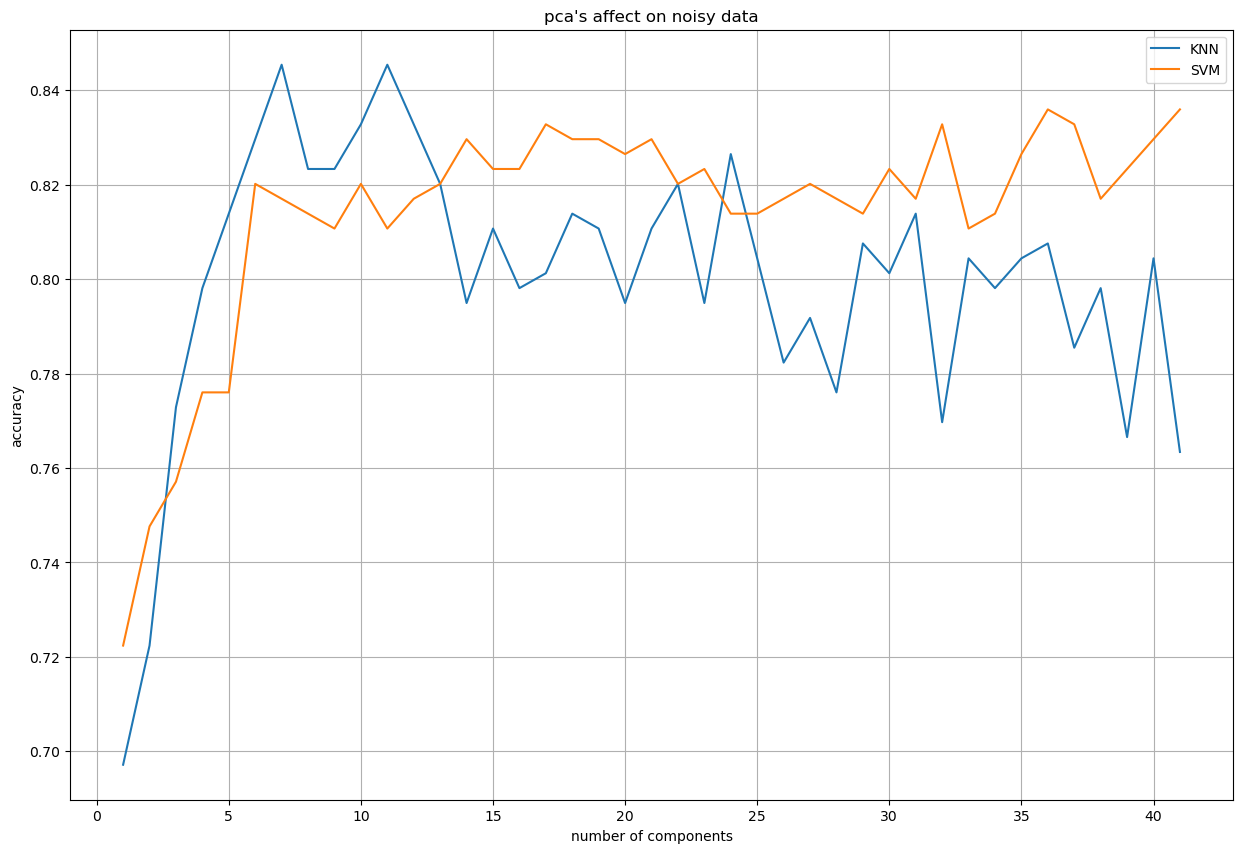

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

seed = 42

def knn_func(best_k, X_train, X_test, y_train, y_test):
    knn = KNeighborsClassifier(best_k)
    knn.fit(X_train, y_train)
    y_predict = knn.predict(X_test)
    noisy_knn_acc = np.mean(y_test == y_predict)
    return noisy_knn_acc

def svm_func(best_c, X_train, X_test, y_train, y_test):
    classifier = SVC(C = best_c)
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    noisy_svm_acc = np.mean(y_pred == y_test)
    return noisy_svm_acc

# standardize and center
scaler = StandardScaler()
X_qsar_std = scaler.fit_transform(X_qsar)

# noise
N = X_qsar_std.shape[0]
noises = 1000
rng = np.random.default_rng(seed)
X_noise = rng.normal(0, 0.5, size = (N, noises))
X_qsar_noisy = np.hstack((X_qsar_std, X_noise))

# train test split
X_train, X_test, y_train, y_test = train_test_split(X_qsar_noisy, y_qsar, test_size = 0.3, random_state = seed)

# noisy knn/svm
noisy_knn_acc = knn_func(qsar_knn_best_k, X_train, X_test, y_train, y_test)
noisy_svm_acc = svm_func(qsar_svm_best_c, X_train, X_test, y_train,y_test)

# PCA knn/svm
max_components = X_qsar_std.shape[1]
pca_knn_acc = []
pca_svm_acc = []
for n in range(1, max_components + 1):
    pca = PCA(n)
    pca_X_train = pca.fit_transform(X_train)
    pca_X_test = pca.transform(X_test)

    pca_knn_acc.append(knn_func(qsar_knn_best_k, pca_X_train, pca_X_test, y_train, y_test))
    pca_svm_acc.append(svm_func(qsar_svm_best_c, pca_X_train, pca_X_test, y_train, y_test))

# graphing
plt.figure(figsize = (15, 10))
plt.plot(range(1, max_components + 1), pca_knn_acc, label = "KNN")
plt.plot(range(1, max_components + 1), pca_svm_acc, label = "SVM")
plt.xlabel("number of components")
plt.ylabel("accuracy")
plt.title("pca's affect on noisy data")
plt.grid(True)
plt.legend()
plt.show()

**As you can see from the graph above, using PCA did not make a large difference in the accuracy for KNN or SVM. This is because it is meant to reduce noise and dimentionality, not to increase accuracy, even though increased accuracy is a possible side affect of more stable data. Along with this, the SVM classifier was able to handle noise better. This is because SVM learns on only a subset of data points, while KNN learns on all of its neighbors, making it more suseptible to noise.**

### Code organization

Both tasks in this assignment require you to run a particular experiment over multiple classifiers, datasets, or pre-processing steps.  In writing your code refrain from repeating the code over and over again.  To achieve that, decompose the task such that your code is modular and concise.  Not only will your code be more readable and elegant, this will also enable you to be more productive.

### Part 3:  Use of AI and other web resources

In the cell below indicate in detail how you used AI and other web resources for this assignment.  If you used AI tools, indicate how useful they were.

**When it comes to mixing AI and my school assignments, I really do my best to not rely on AI. I mainly use it to reword questions or instructions since I usually end up reading them multiple times. Along with this, I will occasionally use it for some help in the code, but I try to use every other resource I have access to before going to LLM's. With this being said, I always make sure I actually understand the concept that I am using AI for, avoiding copying and pasting. I find that this elevates my learning experience instead of having AI do the whole thing. On the other hand, I was able to get a lot of help from the Jupyter notebooks that we do in class for this assignment.**

### Your Report

Answer the questions in the cells reserved for that purpose.

### Submission

Submit your report as a Jupyter notebook via Canvas.  Running the notebook should generate all the plots in your notebook.

### Grading 

```
Grading sheet for assignment 3

Part 1:  50 points
Model selection code for SVM/KNN (40 pts)
Discussion of your results (5 pts)
Code organization (5 pts)

Part 2:  50 points
Baseline SVM/KNN accuracy (10 pt)
SVM/KNN accuracy as a function of number of PCs (25 pts)
Discussion of your results (10 pt)
Code organization (5 pts)

Make sure you address your use of AI and web resources
```

Grading should be based on the following criteria:

  * Code correctness.
  * Code organization.  You code is well organized without unnecessary duplication.
  * Plots and other results are well formatted and easy to understand.
  * Interesting and meaningful observations made where requested.
  * Notebook is readable, well-organized, and concise.
  
